#1. Gradient Descent and Convergence Rate

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
data = np.load('hw1_p1.npy', allow_pickle=True)

## sub-problem 3

In [ ]:
# Assuming the array is structured with x values in the first column and y values in the second column
X = data[:, 0]
y = data[:, 1]

# Re-define the Gaussian feature map function with the provided mu values
def gaussian_feature_map(x, m, mu_m, sigma=0.25):
    return np.exp(-((x - mu_m) ** 2) / (2 * sigma ** 2))

# Construct the design matrix Phi with the updated Gaussian feature map
M = 7  # The number of Gaussian features
mus = [1.25 * m - 3.75 for m in range(M)]  # Centers for the Gaussian basis functions
Phi = np.array([[gaussian_feature_map(x_n, m, mus[m]) for m in range(M)] for x_n in X])

# Calculate the Hessian matrix
Hessian = Phi.T @ Phi

# Calculate the eigenvalues of the Hessian matrix
eigenvalues = np.linalg.eigvals(Hessian)

# The largest eigenvalue (Lipschitz constant L)
L = np.max(eigenvalues)

# Theoretical upper bound for the learning rate
lr_upper_bound = 2 / L

print("Eigenvalues of the Hessian:", list(eigenvalues))
print("Numerical upper bound of learning rate:", lr_upper_bound)


Eigenvalues of the Hessian: [48.56042987385238, 45.32544635645067, 42.65549749953671, 42.92932136830669, 43.33522471860041, 51.920171616338365, 44.95275177263939]
Numerical upper bound of learning rate: 0.0385206739064521


##sub-problem 4

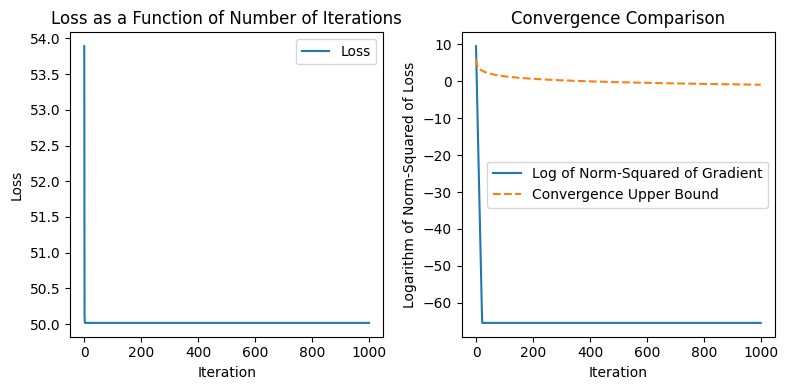

In [ ]:
# Define the loss function for MSE
def compute_loss(Phi, w, y):
    return 0.5 * np.linalg.norm(Phi @ w - y) ** 2

# Define the gradient of the loss function
def compute_gradient(Phi, w, y):
    return Phi.T @ (Phi @ w - y)

# Set the learning rate to the reciprocal of the largest eigenvalue of the Hessian
lr = 1 / L

# Initialize weights to zero
w = np.zeros(M)

# Number of iterations
num_iterations = 1000

# Lists to store the loss value and the norm-squared of the gradient for each iteration
loss_values = []
gradient_norms = []

# Run the gradient descent updates
for t in range(num_iterations):
    # Compute the gradient
    gradient = compute_gradient(Phi, w, y)

    # Update the weights
    w -= lr * gradient

    # Compute the loss
    loss = compute_loss(Phi, w, y)

    # Log the loss and the norm-squared of the gradient
    loss_values.append(loss)
    gradient_norms.append(np.linalg.norm(gradient) ** 2)

# Plot (a): Loss as a function of number of iterations
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(loss_values, label='Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss as a Function of Number of Iterations')
plt.legend()

# Calculate the optimal loss (assuming the last value is close to optimal)
optimal_loss = loss_values[-1]

# Plot (b): Logarithm of the norm-squared of the loss compared with the logarithm of the convergence upper bound
convergence_upper_bound = [np.log(2 * L * (loss_values[0] - optimal_loss) / (t + 1)) for t in range(num_iterations)]
log_gradient_norms = np.log(gradient_norms)

plt.subplot(1, 2, 2)
plt.plot(log_gradient_norms, label='Log of Norm-Squared of Gradient')
plt.plot(convergence_upper_bound, label='Convergence Upper Bound', linestyle='--')
plt.xlabel('Iteration')
plt.ylabel('Logarithm of Norm-Squared of Loss')
plt.title('Convergence Comparison')
plt.legend()

plt.tight_layout()
plt.show()

##sub-problem 5

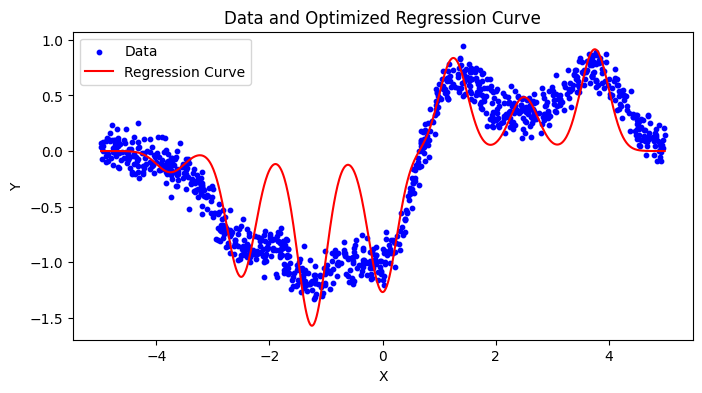

In [ ]:
# Generate a range of x values for plotting the regression curve
x_values = np.linspace(min(X), max(X), 1000)

# Generate predictions for the optimized regression curve
y_pred = Phi @ w

# Generate the regression curve using the optimized weights and the feature map
y_regression_curve = np.array([sum(w[m] * gaussian_feature_map(x, m, mus[m]) for m in range(M)) for x in x_values])

# Plot the data points and the optimized regression curve
plt.figure(figsize=(8, 4))
plt.scatter(X, y, label='Data', color='blue', s=10)  # Data points
plt.plot(x_values, y_regression_curve, label='Regression Curve', color='red')  # Regression curve
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Data and Optimized Regression Curve')
plt.legend()
plt.show()